In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
gdf = gpd.read_file("../data_processed/reaches_model.gpkg", layer="reaches_model")

In [4]:
ELEV = "elev_mean"
SLOPE = "slope_mean"
AREA = "reach_area_stats_max"  # km^2

In [5]:
gdf = gdf.dropna(subset=[ELEV, SLOPE, AREA]).copy()
gdf = gdf[gdf[AREA] > 0].copy()

In [6]:
# suitability curves
def logistic_up(x, x0, k):
    """0..1 increasing curve"""
    return 1 / (1 + np.exp(-k*(x - x0)))

def gaussian_peak(x, mu, sigma):
    """0..1 peak at mu"""
    return np.exp(-0.5*((x - mu)/sigma)**2)

In [7]:
# Elevation: higher is better up to saturation
# Basin-specific midpoint x0 (median) and a gentle slope k
x0 = gdf[ELEV].median()
gdf["s_elev"] = logistic_up(gdf[ELEV].values, x0=x0, k=0.002)

In [8]:
# Slope: prefer moderate slopes (tune mu/sigma later)
# mu=5 degrees, sigma=3 degrees is a reasonable starting point
gdf["s_slope"] = gaussian_peak(gdf[SLOPE].values, mu=5.0, sigma=3.0)

In [9]:
# Drainage area: prefer moderate basin sizes (log space)
logA = np.log10(gdf[AREA].values)
gdf["s_area"] = gaussian_peak(logA, mu=np.median(logA), sigma=np.std(logA)*0.6)

In [10]:
# --- Sensitivity analysis over weights ---
rng = np.random.default_rng(42)
n_runs = 500
top_frac = 0.10

In [11]:
counts = np.zeros(len(gdf), dtype=int)

In [12]:
for _ in range(n_runs):
    w = rng.dirichlet([1,1,1])  # random weights sum to 1
    hsi = w[0]*gdf["s_elev"].values + w[1]*gdf["s_slope"].values + w[2]*gdf["s_area"].values
    thresh = np.quantile(hsi, 1 - top_frac)
    counts += (hsi >= thresh).astype(int)

    gdf["priority_freq"] = counts / n_runs  # 0..1

In [13]:
import os

os.makedirs("outputs", exist_ok=True)
gdf.to_file("outputs/reaches_consensus.gpkg", layer="consensus", driver="GPKG")

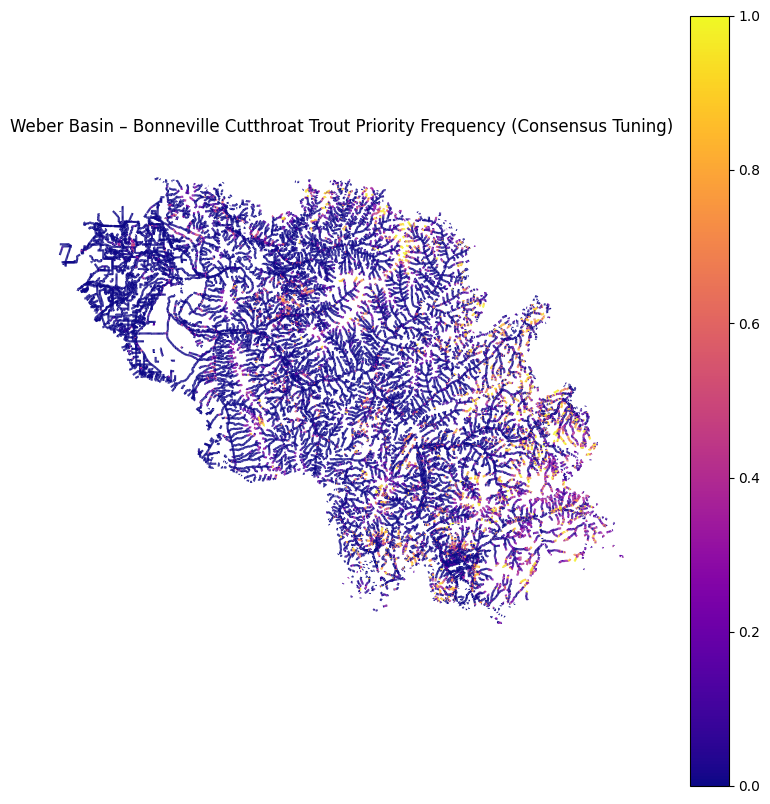

In [16]:
# Plotting the reaches
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()
ax.set_title("Weber Basin – Bonneville Cutthroat Trout Priority Frequency (Consensus Tuning)")
gdf.plot(column="priority_freq", ax=ax, legend=True, cmap="plasma", markersize=5)
plt.show()

How often did each reach land in the top 10% of HSI across 500 random weight combinations?

Yellow reaches (~1.0) almost always top priority

Orange reaches (~0.6-0.8) frequently good

Magenta- rarely good 

and so on

This is not habitat suitability itself, but a test of robustness under uncertainty.